# Machine Learning Fundamentals: Quiz Review Notebook


In [3]:
# Execute this cell to set up the notebook environment (optional)

!pip install numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)



# Machine Learning Fundamentals: Quiz Review

## Question 1: Understanding Model Inputs in Linear Regression

### Question:
For linear regression, the model is \( f_{w,b}(x) = wx + b \).

Which of the following are the **inputs**, or **features**, that are fed into the model and with which the model is expected to make a prediction?

- [ ] \( x \)
- [ ] \( w \) and \( b \)
- [ ] \( m \)
- [ ] \( (x, y) \)

---

### Correct Answer:
✅ **\( x \)** is the correct answer.

---

### Explanation of Correct Answer:

In the linear regression model \( f_{w,b}(x) = wx + b \), the **input feature** is \( x \). Here's why:

- **\( x \)** represents the **input variable** or **feature** that we use to make predictions
- When we want to predict something (like house price), we feed the model the feature \( x \) (like house size)
- The model then computes \( f_{w,b}(x) \) which is the **prediction** (often denoted as ŷ, "y-hat")

Think of it this way:
- **\( x \)** = What you know about the new example (the input)
- **\( f_{w,b}(x) \)** = What the model predicts (the output)

For example, if you're predicting house prices:
- **Input (x)**: House size in square feet (e.g., 2,104 sq ft)
- **Output (f(x))**: Predicted price (e.g., $400,000)

---

### Explanation of Incorrect Options:

| Option | Why It's Incorrect |
|--------|---------------------|
| **\( w \) and \( b \)** | These are **parameters** (also called weights) that the model learns during training. They are not inputs we feed in - they're what the model uses internally to make predictions once trained. |
| **\( m \)** | This represents the **number of training examples** in your dataset. It's a count, not a feature that gets fed into the model for prediction. |
| **\( (x, y) \)** | This notation represents a **complete training example** including both the input \( x \) and the target \( y \). During prediction, we don't have \( y \) yet - that's what we're trying to predict! |

---

### Real-World Example: House Price Prediction

Let's make this concrete with a complete example:



In [1]:
# Real-world example: Predicting house prices
house_size_sqft = 2104  # This is x - the input feature
w = 0.15  # Parameter (slope) - learned during training
b = 50    # Parameter (intercept) - learned during training

# Make a prediction
predicted_price = w * house_size_sqft + b

print(f"🏠 House Size (x): {house_size_sqft} sq ft")
print(f"📊 Model Parameters: w = {w}, b = {b}")
print(f"💰 Predicted Price (ŷ): ${predicted_price:.0f}K")
print(f"\nThe model f(x) = {w}x + {b} took only the size (x) as input")
print(f"and output a prediction of ${predicted_price:.0f}K")

🏠 House Size (x): 2104 sq ft
📊 Model Parameters: w = 0.15, b = 50
💰 Predicted Price (ŷ): $366K

The model f(x) = 0.15x + 50 took only the size (x) as input
and output a prediction of $366K



**Key Insight:** When your client asks "How much can I sell my 2,104 sq ft house for?", they provide only the **size (x)**. The model uses the **parameters (w,b)** that were learned during training to compute the **prediction (ŷ)**. You never feed the parameters as inputs - they're already built into the model!

---

## Question 2: Interpreting the Cost Function

### Question:
For linear regression, if you find parameters \( w \) and \( b \) so that \( J(w, b) \) is very close to zero, what can you conclude?

- [ ] The selected values of the parameters \( w \) and \( b \) cause the algorithm to fit the training set really well.
- [ ] The selected values of the parameters \( w \) and \( b \) cause the algorithm to fit the testing set really poorly.
- [ ] This is never possible -- there must be a bug in the code.

---

### Correct Answer:
✅ **The selected values of the parameters \( w \) and \( b \) cause the algorithm to fit the training set really well.** is the correct answer.

---

### Explanation of Correct Answer:

The **cost function** \( J(w,b) \) measures how well your model fits the training data. Specifically:

- **\( J(w,b) = \frac{1}{2m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \)**
- This calculates the **average squared difference** between predictions and actual values
- **Smaller J means smaller errors** → predictions are closer to actual targets

When \( J(w,b) \) is very close to zero:
- The predictions \( f_{w,b}(x^{(i)}) \) are extremely close to the actual values \( y^{(i)} \) for every training example
- The model has found parameters that make the line pass very close to (or exactly through) all training points
- This indicates **excellent fit on the training data**

---

### Explanation of Incorrect Options:

| Option | Why It's Incorrect |
|--------|---------------------|
| **"fit the testing set really poorly"** | This contradicts the meaning of J. J specifically measures **training set** performance, not testing set. A model could fit training data perfectly (J≈0) but perform poorly on new data (this is called **overfitting**), but that's not what J tells us. |
| **"This is never possible"** | This is absolutely possible! With simple datasets and appropriate models, you can achieve J=0. For example, with 2 data points and a linear model, you can always find a line that passes exactly through both points (J=0). |

---

### Visualizing Different Levels of Fit


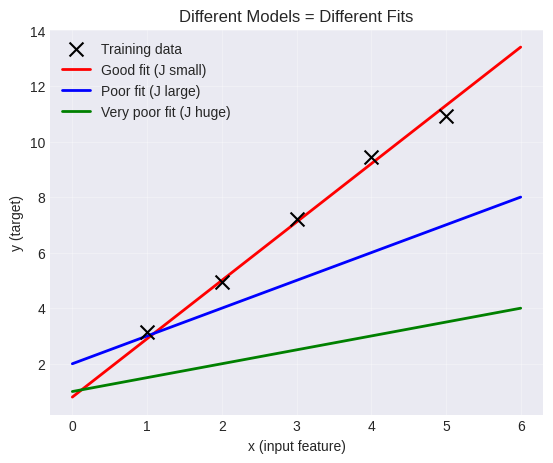

In [4]:
# Create sample data
np.random.seed(42)
x_train = np.array([1, 2, 3, 4, 5])
y_train = 2 * x_train + 1 + np.random.normal(0, 0.3, 5)

# Three different models with different fits
models = [
    {'w': 2.1, 'b': 0.8, 'color': 'red', 'label': 'Good fit (J small)'},
    {'w': 1.0, 'b': 2.0, 'color': 'blue', 'label': 'Poor fit (J large)'},
    {'w': 0.5, 'b': 1.0, 'color': 'green', 'label': 'Very poor fit (J huge)'}
]

plt.figure(figsize=(14, 5))

# Plot 1: Training data with different fits
plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, color='black', s=100, marker='x', label='Training data', zorder=5)

x_line = np.linspace(0, 6, 100)
for model in models:
    y_line = model['w'] * x_line + model['b']
    plt.plot(x_line, y_line, color=model['color'], linewidth=2, label=model['label'])

    # Calculate cost for this model
    predictions = model['w'] * x_train + model['b']
    errors = predictions - y_train
    cost = np.sum(errors**2) / (2 * len(x_train))
    model['cost'] = cost

plt.xlabel('x (input feature)')
plt.ylabel('y (target)')
plt.title('Different Models = Different Fits')
plt.grid(True, alpha=0.3)
plt.legend()

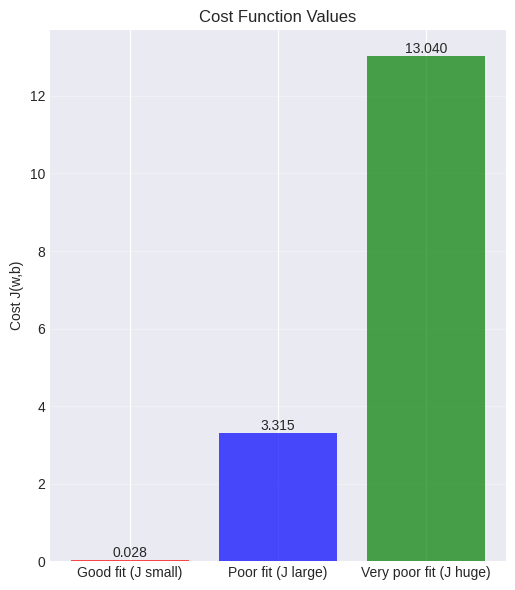

📊 Cost values:
   Good fit (J small): J = 0.0276
   Poor fit (J large): J = 3.3149
   Very poor fit (J huge): J = 13.0402


In [5]:
# Plot 2: Cost values
plt.subplot(1, 2, 2)
models_list = [m['label'] for m in models]
costs = [m['cost'] for m in models]
colors = [m['color'] for m in models]

bars = plt.bar(models_list, costs, color=colors, alpha=0.7)
plt.ylabel('Cost J(w,b)')
plt.title('Cost Function Values')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, cost in zip(bars, costs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{cost:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("📊 Cost values:")
for model in models:
    print(f"   {model['label']}: J = {model['cost']:.4f}")


### Real-World Example: Temperature Conversion

Let's consider a real scenario where J can be exactly zero:


In [6]:
# Perfect linear relationship: Celsius to Fahrenheit conversion
celsius = np.array([0, 10, 20, 30, 40, 100])  # x values
fahrenheit = celsius * 9/5 + 32  # y values (true relationship)

# Our model learns this relationship
w_true = 9/5  # 1.8
b_true = 32   # 32

# Calculate predictions and cost
predictions = w_true * celsius + b_true
errors = predictions - fahrenheit
cost = np.sum(errors**2) / (2 * len(celsius))

print("🌡️  Temperature Conversion Example")
print("-" * 40)
print(f"Input (Celsius): {celsius}")
print(f"Target (Fahrenheit): {fahrenheit}")
print(f"Predictions: {predictions}")
print(f"Errors: {errors}")
print(f"\n📉 Cost J(w,b) = {cost}")

if cost == 0:
    print("\n✅ J = 0! The model perfectly captures the relationship.")
    print("   This is possible because the data follows a perfect linear pattern.")
    print("   Any new Celsius temperature will be converted perfectly to Fahrenheit.")

🌡️  Temperature Conversion Example
----------------------------------------
Input (Celsius): [  0  10  20  30  40 100]
Target (Fahrenheit): [ 32.  50.  68.  86. 104. 212.]
Predictions: [ 32.  50.  68.  86. 104. 212.]
Errors: [0. 0. 0. 0. 0. 0.]

📉 Cost J(w,b) = 0.0

✅ J = 0! The model perfectly captures the relationship.
   This is possible because the data follows a perfect linear pattern.
   Any new Celsius temperature will be converted perfectly to Fahrenheit.


**Key Insight:** In this temperature example, J=0 is not only possible but expected - there's a perfect linear relationship between Celsius and Fahrenheit. In real-world machine learning, data usually has noise, so J will be small but rarely exactly zero.

---

## Summary Table: Key Concepts

| Concept | Symbol | Description | Role in Linear Regression |
|---------|--------|-------------|---------------------------|
| **Input Feature** | \( x \) | What you know about the example | Fed into model to make predictions |
| **Target** | \( y \) | What you're trying to predict | The "right answer" in training data |
| **Parameters** | \( w, b \) | What the model learns | Internal model values that transform input to output |
| **Prediction** | \( ŷ \) or \( f(x) \) | Model's output | \( f(x) = wx + b \) |
| **Cost Function** | \( J(w,b) \) | Measures fit quality | Average squared error between predictions and targets |
| **Training Examples** | \( m \) | Size of dataset | Number of (x,y) pairs used to train |

---

## Key Takeaways

1. **Inputs vs. Parameters**: Never confuse what goes into the model (features \( x \)) with what the model learns (parameters \( w, b \)).

2. **Cost Function Interpretation**:
   - **J small** → Model fits training data well
   - **J = 0** → Perfect fit on training data (possible with clean data)
   - **J large** → Model fits training data poorly

3. **Training vs. Testing**: J measures only **training set** performance. A model with J≈0 on training data might still perform poorly on new data (this is called **overfitting** - a topic for later!).

4. **Real-World Applicability**: Understanding these fundamentals helps you:
   - Debug models when they're not learning properly
   - Communicate clearly with other data scientists
   - Build intuition for more complex algorithms

---

## Practice Questions

Test your understanding:

1. **Q**: If you change the parameters \( w \) and \( b \), what happens to the cost function \( J \)?
   - **A**: It changes! Each (w,b) pair produces a different line and therefore a different cost. Finding the (w,b) that minimizes J is the goal of training.

2. **Q**: Can you have a situation where J is zero but the model is still bad?
   - **A**: Yes! If your training data has outliers or noise, a model that fits it perfectly (J=0) might be **overfitting** and will perform poorly on new data.

3. **Q**: In the model \( f_{w,b}(x) = wx + b \), what are we "learning" during training?
   - **A**: We're learning the optimal values for \( w \) and \( b \) - the parameters that make the line fit the training data best (minimize J).

---

**Remember:** Machine learning is about finding patterns in data. The concepts in these questions - inputs, parameters, and cost functions - are the foundation for EVERY supervised learning algorithm you'll ever learn!